In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox

from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (12, 5)

### Load the AirPassengers dataset

The classic dataset contains:

Monthly observations
January 1949 to December 1960
Number of international airline passengers
144 observations

In [2]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"

df = pd.read_csv(url)

df.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


Convert the date column to a time series index

ARIMA expects observations ordered according to time.

In [3]:
df["Month"] = pd.to_datetime(df["Month"])

df.set_index("Month", inplace=True)

df.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


Inspect the dataset

In [4]:
print("Number of observations:", len(df))
print("\nDate range:")
print(df.index.min(), "to", df.index.max())

print("\nMissing values:")
print(df.isnull().sum())

print("\nSummary statistics:")
print(df.describe())

Number of observations: 144

Date range:
1949-01-01 00:00:00 to 1960-12-01 00:00:00

Missing values:
Passengers    0
dtype: int64

Summary statistics:
       Passengers
count  144.000000
mean   280.298611
std    119.966317
min    104.000000
25%    180.000000
50%    265.500000
75%    360.500000
max    622.000000


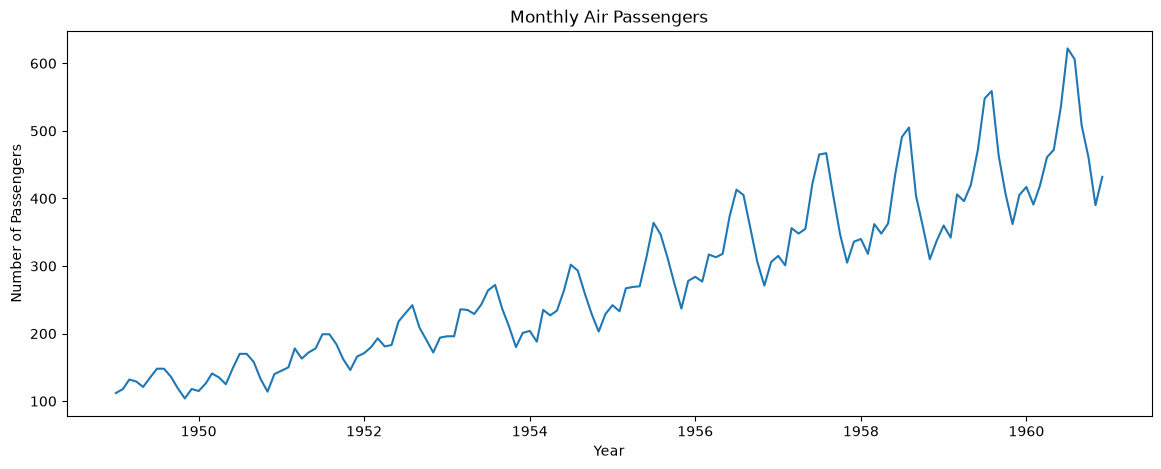

In [5]:
plt.figure(figsize=(14, 5))

plt.plot(df["Passengers"])

plt.title("Monthly Air Passengers")
plt.xlabel("Year")
plt.ylabel("Number of Passengers")

plt.show()

Box–Jenkins Step 1: Check stationarity

ARIMA requires the underlying series to be stationary after differencing.

We can use the Augmented Dickey-Fuller (ADF) test.

Hypotheses

H₀: The series has a unit root → non-stationary.

H₁: The series is stationary.

Usually:

p-value < 0.05 → reject H₀ → stationary
p-value >= 0.05 → fail to reject H₀ → non-stationary

In [6]:
result = adfuller(df["Passengers"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

print("\nCritical Values:")

for key, value in result[4].items():
    print(f"{key}: {value}")

ADF Statistic: 0.8153688792060456
p-value: 0.991880243437641

Critical Values:
1%: -3.4816817173418295
5%: -2.8840418343195267
10%: -2.578770059171598


Apply logarithmic transformation

Because the variance increases as passenger numbers increase, a logarithmic transformation is useful.

This converts:

$$ Y_t $$

into:

Z
t=log(Yt)
The key idea: multiplicative → additive

This is particularly important for the AirPassengers dataset.

The passenger data is commonly viewed as having approximately multiplicative seasonality:

$$ Y_t = T_t \times S_t \times E_t $$

where:

\(T_t\) = trend
\(S_t\) = seasonal component
\(E_t\) = error

The seasonal fluctuations grow as the overall number of passengers grows.

Taking logarithms gives:

$$ \log(Y_t) = \log(T_t) + \log(S_t) + \log(E_t) $$

So the multiplicative relationship becomes additive.

This makes the series more suitable for the classical Box–Jenkins approach.

In [8]:
# Apply logarithmic transformation to stabilize variance
df["LogPassengers"] = np.log(df["Passengers"])

df.head()

,Passengers,LogPassengers
Month,,
1949-01-01,112,4.718499
1949-02-01,118,4.770685
1949-03-01,132,4.882802
1949-04-01,129,4.859812
1949-05-01,121,4.795791


Plot Log Series

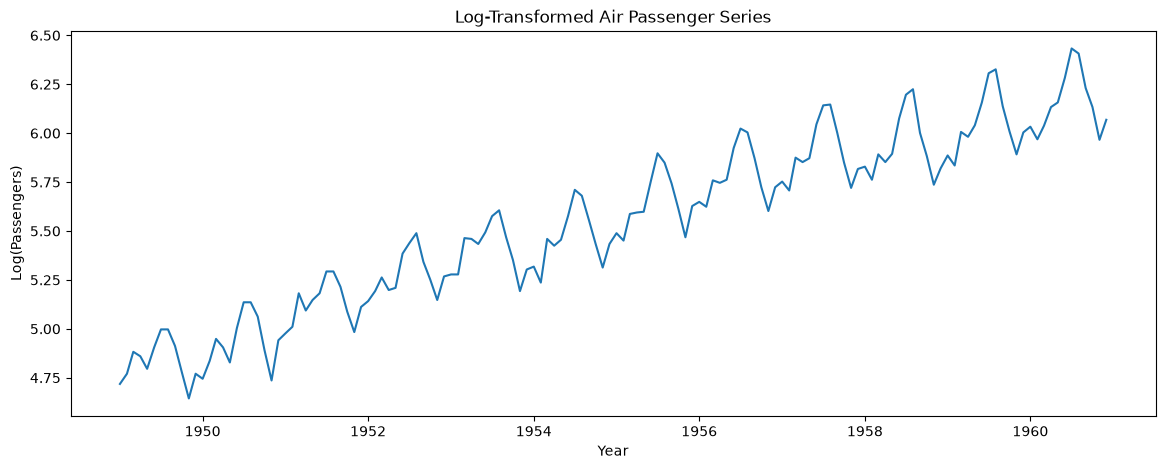

In [9]:
plt.figure(figsize=(14, 5))

plt.plot(df["LogPassengers"])

plt.title("Log-Transformed Air Passenger Series")
plt.xlabel("Year")
plt.ylabel("Log(Passengers)")

plt.show()

In [ ]:
#test ADF for the log-transformed series
result = adfuller(df["LogPassengers"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

print("\nCritical Values:")

for key, value in result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -1.7170170891069665
p-value: 0.4223667747703883

Critical Values:
1%: -3.4816817173418295
5%: -2.8840418343195267
10%: -2.578770059171598


First difference

In [11]:
df["LogDiff"] = df["LogPassengers"].diff()

df.head()

,Passengers,LogPassengers,LogDiff
Month,,,
1949-01-01,112,4.718499,NaN
1949-02-01,118,4.770685,0.052186
1949-03-01,132,4.882802,0.112117
1949-04-01,129,4.859812,-0.022990
1949-05-01,121,4.795791,-0.064022


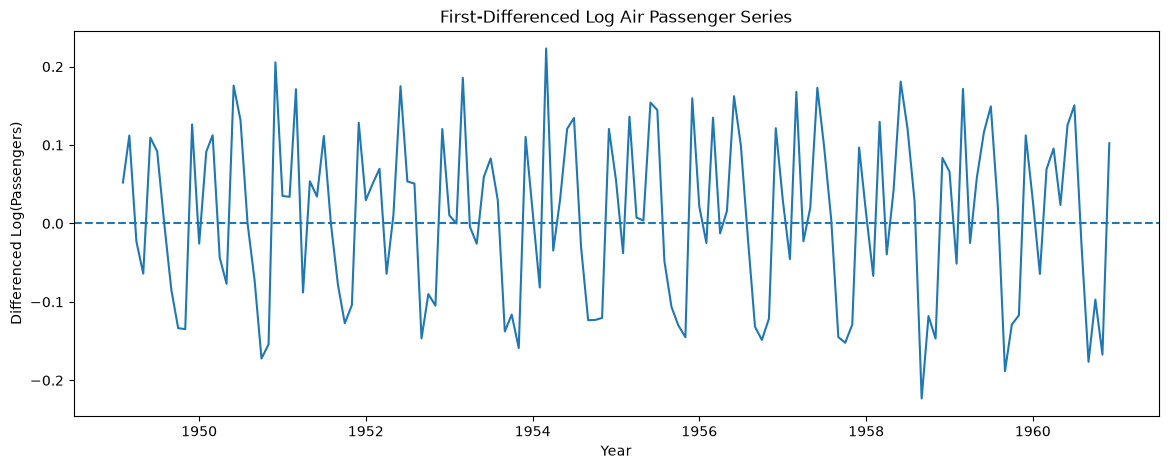

In [15]:
plt.figure(figsize=(14, 5))

plt.plot(df["LogDiff"])

plt.title("First-Differenced Log Air Passenger Series")
plt.xlabel("Year")
plt.ylabel("Differenced Log(Passengers)")

plt.axhline(y=0, linestyle="--")

plt.show()

In [17]:
# check stationary after differencing
diff_series = df["LogDiff"].dropna()

result = adfuller(diff_series)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

print("\nCritical Values:")

for key, value in result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -2.717130598388136
p-value: 0.0711205481508582

Critical Values:
1%: -3.4825006939887997
5%: -2.884397984161377
10%: -2.578960197753906


Box–Jenkins Step 3: Identify p and q

Now we need to determine:

$$ p $$

and

$$ q $$

We use:

ACF → helps identify \(q\)
PACF → helps identify p

In [18]:
#2nd differencing
df["LogDiff2"] = df["LogPassengers"].diff().diff()

In [19]:
#check adf again
result = adfuller(df["LogDiff2"].dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])

print("\nCritical Values:")
for key, value in result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -8.196629132182293
p-value: 7.419304549373899e-13

Critical Values:
1%: -3.4825006939887997
5%: -2.884397984161377
10%: -2.578960197753906


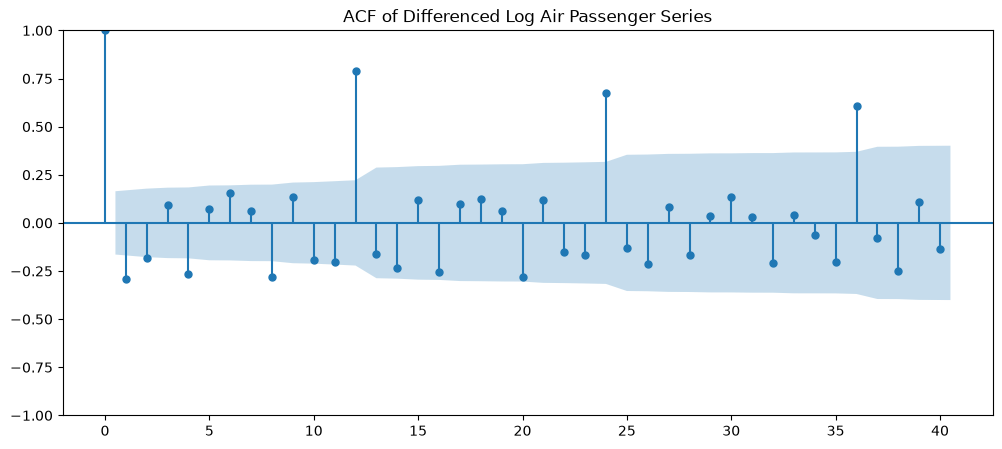

In [24]:
# acf plot
series2=df["LogDiff2"].dropna()
fig, ax = plt.subplots(figsize=(12, 5))

plot_acf(
    #diff_series,
    series2,
    lags=40,
    ax=ax
)

ax.set_title("ACF of Differenced Log Air Passenger Series")

plt.show()

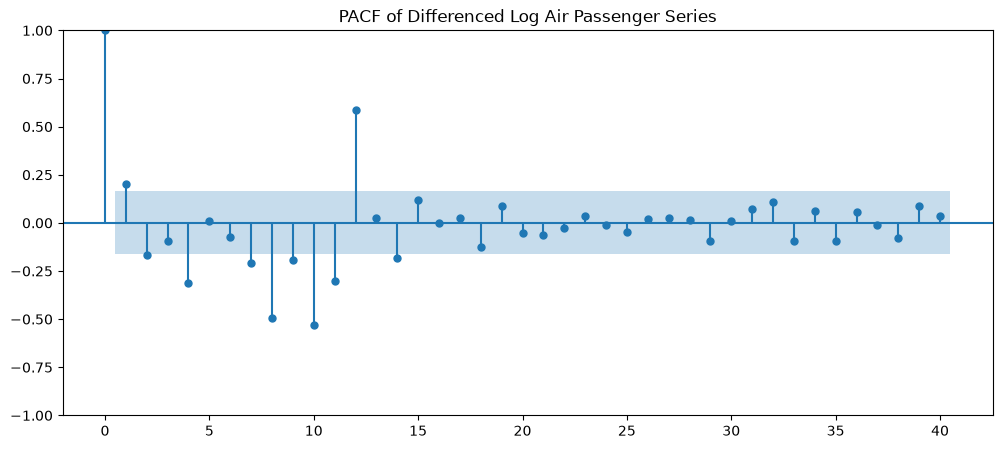

In [21]:
#pacf
fig, ax = plt.subplots(figsize=(12, 5))

plot_pacf(
    diff_series,
    lags=40,
    ax=ax,
    method="ywm"
)

ax.set_title("PACF of Differenced Log Air Passenger Series")

plt.show()

In [28]:
train_size = int(len(df) * 0.8)

train = df.iloc[:train_size]
test = df.iloc[train_size:]

print("Training observations:", len(train))
print("Testing observations :", len(test))

Training observations: 115
Testing observations : 29


In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --------------------------------------------------
# 1. Train-test split
# --------------------------------------------------

train_size = int(len(df) * 0.8)

train = df.iloc[:train_size]
test = df.iloc[train_size:]

print("Training observations:", len(train))
print("Testing observations :", len(test))


# --------------------------------------------------
# 2. Candidate ARIMA models
# --------------------------------------------------

models = [
    (0, 1, 0),
    (1, 1, 0),
    (0, 1, 1),
    (1, 1, 1),
    (2, 1, 0),
    (0, 1, 2),
    (2, 1, 1),
    (1, 1, 2),
    (2, 1, 2),
    (12, 2, 12)
]

results = []


# --------------------------------------------------
# 3. Fit and evaluate each model
# --------------------------------------------------

for order in models:

    # Fit ONLY on training data
    model = ARIMA(
        train["LogPassengers"],
        order=order
    )

    fitted_model = model.fit()

    # Forecast the test period
    forecast_log = fitted_model.forecast(
        steps=len(test)
    )

    # Convert forecast back to original passenger scale
    forecast = np.exp(forecast_log)

    # Actual test values
    actual = test["Passengers"]

    # Evaluation metrics
    mae = mean_absolute_error(actual, forecast)
    mse = mean_squared_error(actual, forecast)
    rmse = np.sqrt(mse)

    results.append({
        "ARIMA": str(order),
        "AIC": fitted_model.aic,
        "BIC": fitted_model.bic,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse
    })


# --------------------------------------------------
# 4. Compare models
# --------------------------------------------------

model_comparison = pd.DataFrame(results)

model_comparison.sort_values("RMSE")

Training observations: 115
Testing observations : 29


,ARIMA,AIC,BIC,MAE,MSE,RMSE
9,"(12, 2, 12)",-311.993067,-243.808371,18.053144,529.021463,23.000467
5,"(0, 1, 2)",-196.569035,-188.360439,68.922631,6751.755893,82.169069
8,"(2, 1, 2)",-199.305146,-185.624154,62.630346,6867.762261,82.871963
7,"(1, 1, 2)",-199.939676,-188.994882,62.102030,6975.551214,83.519765
6,"(2, 1, 1)",-199.699332,-188.754539,61.400108,7013.739300,83.748070
4,"(2, 1, 0)",-193.155455,-184.946860,73.913468,7437.834425,86.242880
0,"(0, 1, 0)",-189.956965,-187.220767,81.448276,8673.931034,93.133941
3,"(1, 1, 1)",-197.221464,-189.012869,84.254055,9278.927911,96.327192
2,"(0, 1, 1)",-193.429561,-187.957164,86.722152,9811.572401,99.053382
1,"(1, 1, 0)",-191.729307,-186.256910,88.396387,10196.269816,100.976581


Box–Jenkins Step 4: Residual diagnostics

This is a critical part of Box–Jenkins modeling.

A good ARIMA model should leave residuals that resemble white noise.

We want:

$$ E(\epsilon_t)=0 $$

and approximately:

$$ Cov(\epsilon_t,\epsilon_{t-k})=0 $$

for \(k!=0\).

In simple terms:

The model should explain the systematic structure, leaving only random errors.

In [32]:
#Examine residuals. Extract residuals
residuals = model_fit.resid

print(residuals.describe())

count    144.000000
mean       0.014268
std        0.442265
min       -2.307064
25%       -0.031944
50%       -0.001341
75%        0.033312
max        4.718499
dtype: float64


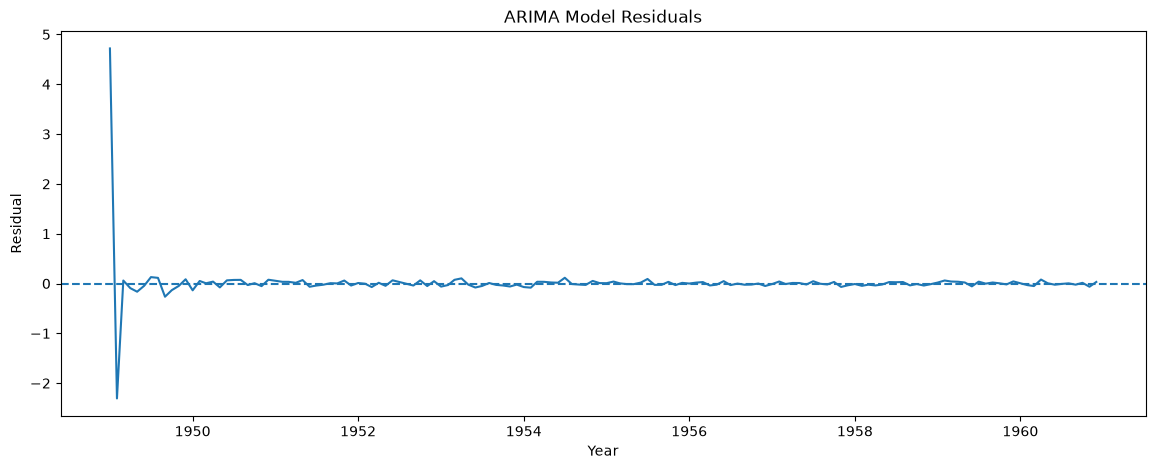

In [34]:
#Plot the residuals
plt.figure(figsize=(14, 5))

plt.plot(residuals)

plt.title("ARIMA Model Residuals")
plt.xlabel("Year")
plt.ylabel("Residual")

plt.axhline(y=0, linestyle="--")

plt.show()

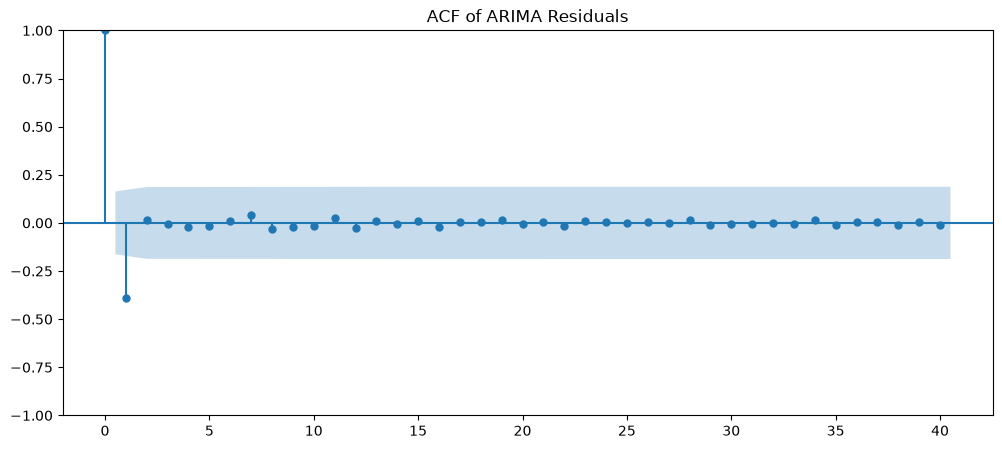

In [35]:
#residual acf
fig, ax = plt.subplots(figsize=(12, 5))

plot_acf(
    residuals.dropna(),
    lags=40,
    ax=ax
)

ax.set_title("ACF of ARIMA Residuals")

plt.show()

In [36]:
#ljung-box test
ljung_box = acorr_ljungbox(
    residuals.dropna(),
    lags=[1, 5, 10, 12, 20, 24],
    return_df=True
)

print(ljung_box)

      lb_stat  lb_pvalue
1   22.602172   0.000002
5   22.746739   0.000377
10  23.268826   0.009797
12  23.491185   0.023834
20  23.645109   0.258238
24  23.710016   0.478276
